In [27]:
import os
import pandas as pd
from tqdm import tqdm
from transformers import pipeline

In [28]:
df = pd.read_csv("rsos_dream_data.tsv", sep="\t")

In [ ]:
go_clf = pipeline(
    "text-classification",
    model="SamLowe/roberta-base-go_emotions",
    top_k=None,
    device=-1
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5212.28it/s]


In [ ]:

keep_cols = [
    "dream_id",
    "dreamer",
    "description",
    "text_dream",
    "emotions_code",
    "NegativeEmotions",
    "A/CIndex",
    "F/CIndex",
    "S/CIndex"
]

df_emotion_model = df[keep_cols].copy()

df_emotion_model = df_emotion_model.dropna(subset=["text_dream"]).reset_index(drop=True)

df_emotion_model = df_emotion_model.rename(columns={
    "description": "dreamer_description",
    "text_dream": "dream_text",
    "NegativeEmotions": "hvc_negative_emotions",
    "A/CIndex": "hvc_aggression_per_character",
    "F/CIndex": "hvc_friendliness_per_character",
    "S/CIndex": "hvc_sexuality_per_character"
})

df_emotion_model["n_words"] = df_emotion_model["dream_text"].str.split().str.len()

print(df_emotion_model.shape)
display(df_emotion_model.head())

(21000, 10)


,dream_id,dreamer,dreamer_description,dream_text,emotions_code,hvc_negative_emotions,hvc_aggression_per_character,hvc_friendliness_per_character,hvc_sexuality_per_character,n_words
0,1,alta,Alta: a detailed dreamer,"The one at the Meads's house, where it's bigge...",NaN,0.0,0.200000,0.200000,0.0,167
1,2,alta,Alta: a detailed dreamer,I'm at a family reunion in a large fine house ...,SD 2IKA,1.0,0.666667,0.000000,0.0,258
2,3,alta,Alta: a detailed dreamer,I watch a plane fly past and shortly realize i...,"SD 1ISA, AP D, AP D",1.0,0.428571,0.000000,0.0,330
3,4,alta,Alta: a detailed dreamer,Me pulling the green leaves and berries off so...,"SD 2ISA, SD D",1.0,0.235294,0.117647,0.0,468
4,5,alta,Alta: a detailed dreamer,I'm in a room that reminds me of (but definite...,"AP D, AP D, AP 1MSA, CO D, SD D, AP D",1.0,1.333333,0.166667,0.0,561


In [31]:
macro_emotion_map = {
    "anger": [
        "anger",
        "annoyance"
    ],
    
    "fear_anxiety": [
        "fear",
        "nervousness"
    ],
    
    "sadness_loss": [
        "sadness",
        "grief",
        "disappointment"
    ],
    
    "joy_amusement": [
        "joy",
        "amusement",
        "excitement"
    ],
    
    "love_trust": [
        "love",
        "caring",
        "gratitude",
        "admiration",
        "approval"
    ],
    
    "surprise_realization": [
        "surprise",
        "realization"
    ],
    
    "disgust_rejection": [
        "disgust",
        "disapproval"
    ],
    
    "curiosity_desire": [
        "curiosity",
        "desire"
    ],
    
    "optimism_hope": [
        "optimism",
        "relief"
    ],
    
    "shame_remorse": [
        "embarrassment",
        "remorse"
    ]
}

macro_cols = list(macro_emotion_map.keys())

In [32]:
def split_text_into_chunks(text, max_words=180):
    words = str(text).split()
    
    if len(words) == 0:
        return []
    
    chunks = []
    
    for i in range(0, len(words), max_words):
        chunk = " ".join(words[i:i + max_words])
        chunks.append(chunk)
    
    return chunks

In [ ]:
def classify_dream_goemotions(text, max_words=180):
    chunks = split_text_into_chunks(text, max_words=max_words)
    
    if len(chunks) == 0:
        output = {macro: 0.0 for macro in macro_cols}
        output["neutral_score"] = 0.0
        output["dominant_macro_emotion"] = "no_text"
        output["dominant_macro_score"] = 0.0
        output["macro_emotion_margin"] = 0.0
        output["n_chunks"] = 0
        return output
    
    results = go_clf(
        chunks,
        truncation=True,
        batch_size=8
    )
    
    if len(chunks) == 1 and isinstance(results[0], dict):
        results = [results]
    
    fine_scores_total = {}
    
    for chunk_result in results:
        for item in chunk_result:
            label = item["label"].lower()
            score = item["score"]
            fine_scores_total[label] = fine_scores_total.get(label, 0.0) + score
    
    fine_scores_avg = {
        label: score / len(chunks)
        for label, score in fine_scores_total.items()
    }
    
    macro_scores = {}
    
    for macro, labels in macro_emotion_map.items():
        macro_scores[macro] = sum(
            fine_scores_avg.get(label, 0.0)
            for label in labels
        )
    
    macro_scores["neutral_score"] = fine_scores_avg.get("neutral", 0.0)
    
    dominant_macro = max(macro_cols, key=lambda x: macro_scores[x])
    dominant_score = macro_scores[dominant_macro]
    
    sorted_macro_scores = sorted(
        [macro_scores[m] for m in macro_cols],
        reverse=True
    )
    
    if len(sorted_macro_scores) >= 2:
        margin = sorted_macro_scores[0] - sorted_macro_scores[1]
    else:
        margin = 0.0
    
    macro_scores["dominant_macro_emotion"] = dominant_macro
    macro_scores["dominant_macro_score"] = dominant_score
    macro_scores["macro_emotion_margin"] = margin
    macro_scores["n_chunks"] = len(chunks)
    
    return macro_scores

In [ ]:
output_file = "dreams_goemotions_10macro_partial.csv"
final_output_file = "dreams_goemotions_10macro_full.csv"

save_every = 500

all_results = []

for i, row in tqdm(
    df_emotion_model.iterrows(),
    total=len(df_emotion_model),
    desc="Classifying dreams"
):
    scores = classify_dream_goemotions(row["dream_text"])
    all_results.append(scores)
    
    if (i + 1) % save_every == 0:
        partial_scores = pd.DataFrame(all_results)
        
        partial_df = pd.concat(
            [
                df_emotion_model.iloc[:len(partial_scores)].reset_index(drop=True),
                partial_scores.reset_index(drop=True)
            ],
            axis=1
        )
        
        partial_df.to_csv(output_file, index=False)
        print(f"Saved {len(partial_df)} rows")

scores_df = pd.DataFrame(all_results)

df_goemotions = pd.concat(
    [
        df_emotion_model.reset_index(drop=True),
        scores_df.reset_index(drop=True)
    ],
    axis=1
)

df_goemotions.to_csv(final_output_file, index=False)

print("Completed.")
print(df_goemotions.shape)

display(df_goemotions.head())

Classifying dreams:   2%|▏         | 500/21000 [07:34<1:46:13,  3.22it/s] 

Saved 500 rows


Classifying dreams:   5%|▍         | 1000/21000 [10:59<4:18:28,  1.29it/s]

Saved 1000 rows


Classifying dreams:   7%|▋         | 1500/21000 [15:01<3:00:22,  1.80it/s] 

...

Saved 20500 rows


Classifying dreams: 100%|██████████| 21000/21000 [2:28:00<00:00,  2.36it/s]

Saved 21000 rows


Completed.
(21000, 25)


,dream_id,dreamer,dreamer_description,dream_text,emotions_code,hvc_negative_emotions,hvc_aggression_per_character,hvc_friendliness_per_character,hvc_sexuality_per_character,n_words,...,surprise_realization,disgust_rejection,curiosity_desire,optimism_hope,shame_remorse,neutral_score,dominant_macro_emotion,dominant_macro_score,macro_emotion_margin,n_chunks
0,1,alta,Alta: a detailed dreamer,"The one at the Meads's house, where it's bigge...",NaN,0.0,0.200000,0.200000,0.0,167,...,0.014740,0.002547,0.003818,0.009989,0.000501,0.415393,love_trust,0.591055,0.524364,1
1,2,alta,Alta: a detailed dreamer,I'm at a family reunion in a large fine house ...,SD 2IKA,1.0,0.666667,0.000000,0.0,258,...,0.054428,0.008009,0.003165,0.008478,0.003452,0.743197,sadness_loss,0.231384,0.176956,2
2,3,alta,Alta: a detailed dreamer,I watch a plane fly past and shortly realize i...,"SD 1ISA, AP D, AP D",1.0,0.428571,0.000000,0.0,330,...,0.741522,0.013562,0.007984,0.015520,0.026351,0.239707,surprise_realization,0.741522,0.684901,2
3,4,alta,Alta: a detailed dreamer,Me pulling the green leaves and berries off so...,"SD 2ISA, SD D",1.0,0.235294,0.117647,0.0,468,...,0.047865,0.033027,0.100251,0.015649,0.007594,0.469779,sadness_loss,0.289924,0.189673,3
4,5,alta,Alta: a detailed dreamer,I'm in a room that reminds me of (but definite...,"AP D, AP D, AP 1MSA, CO D, SD D, AP D",1.0,1.333333,0.166667,0.0,561,...,0.378347,0.009846,0.020596,0.026616,0.007565,0.390219,surprise_realization,0.378347,0.230010,4


In [39]:
print("Shape nuovo dataset:", df_goemotions.shape)

display(df_goemotions.head())
display(df_goemotions.dtypes)
display(df_goemotions.isna().sum().sort_values(ascending=False).head(20))

Shape nuovo dataset: (21000, 25)


,dream_id,dreamer,dreamer_description,dream_text,emotions_code,hvc_negative_emotions,hvc_aggression_per_character,hvc_friendliness_per_character,hvc_sexuality_per_character,n_words,...,surprise_realization,disgust_rejection,curiosity_desire,optimism_hope,shame_remorse,neutral_score,dominant_macro_emotion,dominant_macro_score,macro_emotion_margin,n_chunks
0,1,alta,Alta: a detailed dreamer,"The one at the Meads's house, where it's bigge...",NaN,0.0,0.200000,0.200000,0.0,167,...,0.014740,0.002547,0.003818,0.009989,0.000501,0.415393,love_trust,0.591055,0.524364,1
1,2,alta,Alta: a detailed dreamer,I'm at a family reunion in a large fine house ...,SD 2IKA,1.0,0.666667,0.000000,0.0,258,...,0.054428,0.008009,0.003165,0.008478,0.003452,0.743197,sadness_loss,0.231384,0.176956,2
2,3,alta,Alta: a detailed dreamer,I watch a plane fly past and shortly realize i...,"SD 1ISA, AP D, AP D",1.0,0.428571,0.000000,0.0,330,...,0.741522,0.013562,0.007984,0.015520,0.026351,0.239707,surprise_realization,0.741522,0.684901,2
3,4,alta,Alta: a detailed dreamer,Me pulling the green leaves and berries off so...,"SD 2ISA, SD D",1.0,0.235294,0.117647,0.0,468,...,0.047865,0.033027,0.100251,0.015649,0.007594,0.469779,sadness_loss,0.289924,0.189673,3
4,5,alta,Alta: a detailed dreamer,I'm in a room that reminds me of (but definite...,"AP D, AP D, AP 1MSA, CO D, SD D, AP D",1.0,1.333333,0.166667,0.0,561,...,0.378347,0.009846,0.020596,0.026616,0.007565,0.390219,surprise_realization,0.378347,0.230010,4


dream_id                            int64
dreamer                               str
dreamer_description                   str
dream_text                            str
emotions_code                         str
hvc_negative_emotions             float64
hvc_aggression_per_character      float64
hvc_friendliness_per_character    float64
hvc_sexuality_per_character       float64
n_words                             int64
anger                             float64
fear_anxiety                      float64
sadness_loss                      float64
joy_amusement                     float64
love_trust                        float64
surprise_realization              float64
disgust_rejection                 float64
curiosity_desire                  float64
optimism_hope                     float64
shame_remorse                     float64
neutral_score                     float64
dominant_macro_emotion                str
dominant_macro_score              float64
macro_emotion_margin              

emotions_code                     9914
dream_id                             0
dreamer                              0
dreamer_description                  0
dream_text                           0
hvc_negative_emotions                0
hvc_aggression_per_character         0
hvc_friendliness_per_character       0
hvc_sexuality_per_character          0
n_words                              0
anger                                0
fear_anxiety                         0
sadness_loss                         0
joy_amusement                        0
love_trust                           0
surprise_realization                 0
disgust_rejection                    0
curiosity_desire                     0
optimism_hope                        0
shame_remorse                        0
dtype: int64

In [40]:
emotion_distribution = (
    df_goemotions["dominant_macro_emotion"]
    .value_counts()
    .reset_index()
)

emotion_distribution.columns = ["dominant_macro_emotion", "count"]

emotion_distribution["percentage"] = (
    emotion_distribution["count"] / len(df_goemotions) * 100
).round(2)

display(emotion_distribution)

,dominant_macro_emotion,count,percentage
0,surprise_realization,5675,27.02
1,love_trust,4086,19.46
2,sadness_loss,3276,15.60
3,joy_amusement,2741,13.05
4,fear_anxiety,2066,9.84
5,anger,1485,7.07
6,curiosity_desire,551,2.62
7,disgust_rejection,506,2.41
8,shame_remorse,493,2.35
9,optimism_hope,121,0.58


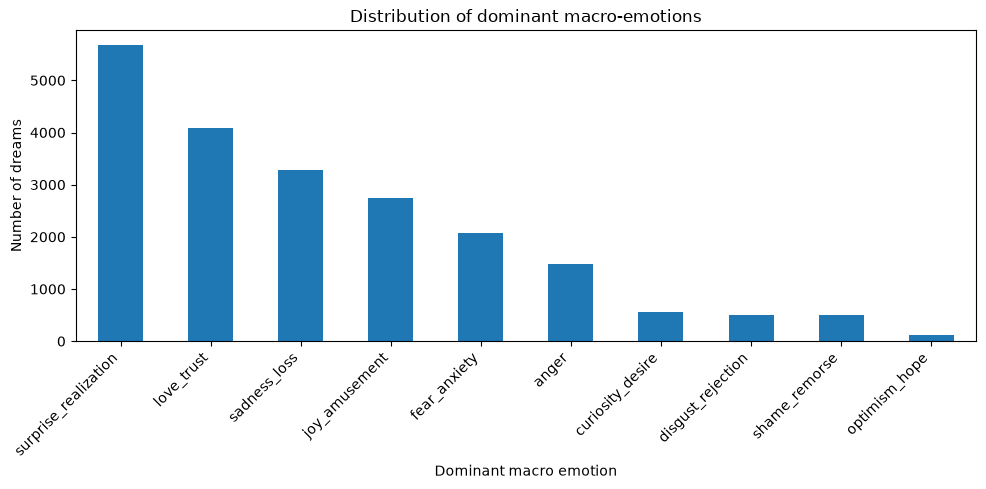

In [41]:
import matplotlib.pyplot as plt

emotion_counts = df_goemotions["dominant_macro_emotion"].value_counts()

plt.figure(figsize=(10, 5))
emotion_counts.plot(kind="bar")
plt.xlabel("Dominant macro emotion")
plt.ylabel("Number of dreams")
plt.title("Distribution of dominant macro-emotions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()